#**1) Problem**

Employee attrition is a common problem in many organizations, where employees leave their jobs for different reasons. This can cause issues such as higher costs, loss of skilled workers, and lower productivity.

The main challenge is understanding why employees leave, since many factors can influence their decision, Even though companies have a lot of employee data, it is often difficult to use it to find clear patterns.

This problem is important because high employee turnover can negatively affect the organization’s performance and stability.


# **2) Data Mining Task**

The problem of employee attrition is formulated as a data mining task using two techniques:

- **Classification:** Used to predict whether an employee will
  leave the company or stay, based on historical employee data.
  Decision Tree models with Gini Index and Entropy are applied
  for this purpose.

- **Clustering:** Used to group employees with similar
  characteristics in order to discover hidden patterns in the
  data. The K-Means algorithm is applied with different values
  of K (2, 3, and 4).

#**3) Data**
The dataset used in this project contains 74498 records (instances) and 24 attributes (features) related to employee information. These attributes include both numerical features (such as Age, Monthly Income, and Years at Company) and categorical features (such as Gender, Job Role, and Work-Life Balance).

The class lable is Attrition, which indicates whether an employee stayed or left the company:
- Attrition = No (employees who stayed): [39128] instances
- Attrition = Yes (employees who left): [35370] instances

**ٍSample of the dataset before preprocessing**

In [ ]:
import pandas as pd

# Load raw dataset
raw_df = pd.read_csv("Raw_dataset.csv")

# Create a copy for preprocessing
df_raw_copy = raw_df.copy()

# Display first rows of the RAW dataset
print("Raw Dataset Snapshot:")
display(raw_df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'Raw_dataset.csv'

## **4) Data Preprocessing:**
data preprocessing is a crucial step used to prepare raw data for analysis by improving its quality and transforming it into a suitable format for data mining techniques.

 Applied Techniques:
  * Normalization for numerical variables such as Age and Monthly
Income to standardize their ranges.
  * Discretization of continuous variables like Years at Company into categories to improve interpretability.
  * Label Encoding to convert categorical variables like Attrition and Work-Life Balance into numerical values for modeling.
  * Feature Selection using Random Forest to identify the most important features, such as Monthly Income and Age.

**ٍSample of the dataset after preprocessing**

In [ ]:
import pandas as pd
df = pd.read_csv("Preprocessed_data.csv")
df.head()

,Job Level,Marital Status,Distance from Home,Monthly Income,Company Tenure,Age,Years at Company,Remote Work,Work-Life Balance,Number of Dependents,Attrition
0,1,1,0.214286,0.279032,0.690476,0.317073,0.36,0,0,0.000000,1
1,1,0,0.204082,0.288682,0.150794,1.000000,0.06,0,3,0.500000,1
2,1,1,0.102041,0.464585,0.571429,0.146341,0.18,0,2,0.500000,1
3,1,2,0.265306,0.185150,0.380952,0.439024,0.12,1,2,0.333333,1
4,2,0,0.714286,0.240903,0.523810,0.926829,0.80,0,1,0.000000,1


In this step, we are performing a value count for the 'Attrition' column to understand the distribution of the target variable.

In [ ]:
print(df['Attrition'].value_counts())

Attrition
1    39128
0    35370
Name: count, dtype: int64


# **5) Data Mining Technique:**
For this project, two data mining techniques will be applied: classification and clustering

##**5.1) Classfication** <br>
 In this project, a Decision Tree Classifier will be applied because it is simple, effective, and easy to interpret. It can handle structured data and show how decisions are made based on the dataset features.

For implementation in Python, the scikit-learn package will be used:

* from sklearn.tree import DecisionTreeClassifier
* from sklearn.model_selection import train_test_split
* from sklearn.metrics import accuracy_score, confusion_matrix

First, the dataset will be divided into training and testing sets
 * using train_test_split().

Then, the Decision Tree model will be built using
* DecisionTreeClassifier().

Two splitting criteria will be tested:

* Entropy (Information Gain) using criterion='entropy'
* Gini Index using criterion='gini'

After training the model with
* .fit(X_train, y_train)

predictions will be generated using
* .predict(X_test).<br>

The model performance will then be evaluated using:

* accuracy_score() to measure prediction accuracy
* confusion_matrix() to compare actual and predicted classes

In [ ]:
## Loading Data :
##The preprocessed dataset was loaded to be used for the classification task.
import pandas as pd
df = pd.read_csv("Preprocessed_data.csv")
df.head()


,Job Level,Marital Status,Distance from Home,Monthly Income,Company Tenure,Age,Years at Company,Remote Work,Work-Life Balance,Number of Dependents,Attrition
0,1,1,0.214286,0.279032,0.690476,0.317073,0.36,0,0,0.000000,1
1,1,0,0.204082,0.288682,0.150794,1.000000,0.06,0,3,0.500000,1
2,1,1,0.102041,0.464585,0.571429,0.146341,0.18,0,2,0.500000,1
3,1,2,0.265306,0.185150,0.380952,0.439024,0.12,1,2,0.333333,1
4,2,0,0.714286,0.240903,0.523810,0.926829,0.80,0,1,0.000000,1


 Importing Required Libraries
The required libraries were imported to load the dataset, split the data, build the Decision Tree classifier, evaluate the model, and visualize the decision tree.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn import tree


The dataset was divided into input features and the target variable. The target variable is Attrition.

In [ ]:
fn = df.columns.tolist()
fn.remove("Attrition")

X = df[fn]
y = df["Attrition"]

print("Features:")
print(fn)
print("\nTarget:")
print(y.name)

Features:
['Job Level', 'Marital Status', 'Distance from Home', 'Monthly Income', 'Company Tenure', 'Age', 'Years at Company', 'Remote Work', 'Work-Life Balance', 'Number of Dependents']

Target:
Attrition


####**5.1.1) Gini Index**

  **The first experiment**

 **90%** of the data was used for **training** and **10%** for **testing**.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=1, stratify=y
)

model_gini_90 = DecisionTreeClassifier(criterion="gini", random_state=1)
model_gini_90.fit(X_train, y_train)
y_pred = model_gini_90.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Metrics
accuracy    = metrics.accuracy_score(y_test, y_pred)
precision   = metrics.precision_score(y_test, y_pred, zero_division=0)
sensitivity = metrics.recall_score(y_test, y_pred, zero_division=0)
specificity = TN / (TN + FP)

print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Confusion Matrix:
[[2212 1325]
 [1316 2597]]
Accuracy:    0.6455
Precision:   0.6622
Sensitivity: 0.6637
Specificity: 0.6254


The Decision Tree classifier using the Gini index was applied using a 90/10 train-test split. The model achieved an accuracy of 64.55%, precision of 66.22%, sensitivity of 66.37% and specifity of 62.54%.

The confusion matrix shows that the model correctly classified 2212 employees who stayed and 2597 employees who left the company. However, some misclassifications occurred, with 1325 employees predicted as leaving while they actually stayed, and 1316 employees predicted as staying while they actually left.

 **The seconed experiment**

  **80%** of the data was used for **training** and **20%** for **testing**.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

model_gini_80 = DecisionTreeClassifier(criterion="gini", random_state=1)
model_gini_80.fit(X_train, y_train)
y_pred = model_gini_80.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Metrics
accuracy    = metrics.accuracy_score(y_test, y_pred)
precision   = metrics.precision_score(y_test, y_pred, zero_division=0)
sensitivity = metrics.recall_score(y_test, y_pred, zero_division=0)
specificity = TN / (TN + FP)

print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Confusion Matrix:
[[4431 2643]
 [2695 5131]]
Accuracy:    0.6417
Precision:   0.6600
Sensitivity: 0.6556
Specificity: 0.6264


The Decision Tree classifier using the Gini index was also evaluated using an 80/20 train-test split. The model achieved an accuracy of 64.17%, precision of 66%, sensitivity of 65.56% and specifity of 62.64%.

According to the confusion matrix, the model correctly classified 4431 employees who stayed and 5131 employees who left the company. However, some misclassifications occurred, where 2643 employees were predicted as leaving while they actually stayed, and 2695 employees were predicted as staying while they actually left.

**The third experiment**

 **70%** of the data was used for **training** and **30%** for **testing**.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

model_gini_70 = DecisionTreeClassifier(criterion="gini", random_state=1)
model_gini_70.fit(X_train, y_train)
y_pred = model_gini_70.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Metrics
accuracy    = metrics.accuracy_score(y_test, y_pred)
precision   = metrics.precision_score(y_test, y_pred, zero_division=0)
sensitivity = metrics.recall_score(y_test, y_pred, zero_division=0)
specificity = TN / (TN + FP)

print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Confusion Matrix:
[[6666 3945]
 [3972 7767]]
Accuracy:    0.6458
Precision:   0.6632
Sensitivity: 0.6616
Specificity: 0.6282


The Decision Tree classifier using the Gini index was also evaluated using a 70/30 train-test split. The model achieved an accuracy of 64.58%, precision of 66.32%, sensitivity of 66.16% and specifity of 62.82%.

The confusion matrix shows that 6666 employees who stayed and 7767 employees who left the company were correctly classified. However, some misclassifications occurred, where 3945 employees were predicted as leaving while they actually stayed, and 3972 employees were predicted as staying while they actually left.

####**5.1.2) IG Entropy**

 **The first experiment**

  **90%** of the data was used for **training** and **10%** for **testing**.


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=1
)

model_entropy_90 = DecisionTreeClassifier(criterion="entropy", random_state=1)
model_entropy_90.fit(X_train, y_train)
y_pred = model_entropy_90.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Metrics
accuracy    = metrics.accuracy_score(y_test, y_pred)
precision   = metrics.precision_score(y_test, y_pred, zero_division=0)
sensitivity = metrics.recall_score(y_test, y_pred, zero_division=0)
specificity = TN / (TN + FP)

print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Confusion Matrix:
[[2229 1276]
 [1362 2583]]
Accuracy:    0.6459
Precision:   0.6693
Sensitivity: 0.6548
Specificity: 0.6359


The Decision Tree classifier using the Entropy criterion was also evaluated using an 90/10 train-test split. The model achieved an accuracy of 64.59%, precision of 66.93%, sensitivity of 65.48% and specifity of 63.59%.

According to the confusion matrix, the model correctly classified (2229) employees who stayed and (2583) employees who left the company. However, some misclassifications occurred, where (1276 ) employees were predicted as leaving while they actually stayed, and (1362) employees were predicted as staying while they actually left.

**The second experiment**

 **80%** of the data was used for **training** and **20%** for **testing**.

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

model_entropy_80 = DecisionTreeClassifier(criterion="entropy", random_state=1)
model_entropy_80.fit(X_train, y_train)
y_pred = model_entropy_80.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Metrics
accuracy    = metrics.accuracy_score(y_test, y_pred)
precision   = metrics.precision_score(y_test, y_pred, zero_division=0)
sensitivity = metrics.recall_score(y_test, y_pred, zero_division=0)
specificity = TN / (TN + FP)

print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Confusion Matrix:
[[4377 2658]
 [2657 5208]]
Accuracy:    0.6433
Precision:   0.6621
Sensitivity: 0.6622
Specificity: 0.6222


The Decision Tree classifier using the Entropy criterion was evaluated using an 80/20 train-test split. The model achieved an accuracy of 64.33%, precision of 66.21%, sensitivity of 66.22% and specifity of 62.22%.

According to the confusion matrix, the model correctly classified 4,377 employees who stayed and 5,208 employees who left the company. However, some misclassifications occurred, where 2,658 employees who actually stayed were predicted as leaving, and 2,657 employees who actually left were predicted as staying.

**The third experiment**

**70%** of the data was used for **training** and **30%** for **testing**.


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

model_entropy_70 = DecisionTreeClassifier(criterion="entropy", random_state=1)
model_entropy_70.fit(X_train, y_train)
y_pred = model_entropy_70.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Metrics
accuracy    = metrics.accuracy_score(y_test, y_pred)
precision   = metrics.precision_score(y_test, y_pred, zero_division=0)
sensitivity = metrics.recall_score(y_test, y_pred, zero_division=0)
specificity = TN / (TN + FP)

print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Confusion Matrix:
[[6622 3973]
 [3846 7909]]
Accuracy:    0.6502
Precision:   0.6656
Sensitivity: 0.6728
Specificity: 0.6250


The Decision Tree classifier using the Entropy criterion was also evaluated using an 80/20 train-test split. The model achieved an accuracy of 65.02%, precision of 66.56%, sensitivity of 67.28% and specifity of 62.5%.

According to the confusion matrix, the model correctly classified (6622) employees who stayed and (7909) employees who left the company. However, some misclassifications occurred, where (3973 ) employees were predicted as leaving while they actually stayed, and (3846) employees were predicted as staying while they actually left.

---------------------------------------------------------------------------------------------------------------------------------------------------------------

##**5.2) Clustring**
The clustering technique will be used to group similar records in the dataset without using the class label. In this project, K-Means clustering will be applied to discover hidden patterns and segment the data into clusters.

For implementation in Python, the following packages will be used:

*   from sklearn.cluster import KMeans
*   import matplotlib.pyplot as plt
*   import seaborn as sns
*   from sklearn.metrics import silhouette_score
*   from yellowbrick.cluster import SilhouetteVisualizer

Since K-Means works with numeric data, only numerical attributes will be selected using:

*   df.select_dtypes(include=['number'])

Then, the clustering model will be created for three values of K (2, 3, and 4) using:
*   KMeans(n_clusters=k, random_state=42, n_init=10)

The clusters will be assigned using
*  .fit_predict().

To visualize the clustering results, scatter plots are generated using Matplotlib and Seaborn. The data is projected into two dimensions (using PCA) and colored based on the assigned clusters.

Finally, the clustering quality will be examined using two metrics:

*  inertia: measures how compact the formed clusters are, obtained through k_model.inertia_
*  Silhouette Score: measures how well each point fits its cluster, obtained through silhouette_score()
*  Elbow Method will also be used to visually identify the optimal number of clusters (K).

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
# 1. Select only numerical attributes for clustering
numeric_df_final = df.select_dtypes(include=['number'])

# Drop the class label column ('Attrition') if it exists in the numerical selection
# to ensure the model focuses only on patterns and not the target variable.
if 'Attrition' in numeric_df_final.columns:
    numeric_df_final = numeric_df_final.drop(columns=['Attrition'])

# Display the first few rows of the final DataFrame for clustering
print("Numerical features for clustering:")
display(numeric_df_final.head())

Numerical features for clustering:


,Job Level,Marital Status,Distance from Home,Monthly Income,Company Tenure,Age,Years at Company,Remote Work,Work-Life Balance,Number of Dependents
0,1,1,0.214286,0.279032,0.690476,0.317073,0.36,0,0,0.000000
1,1,0,0.204082,0.288682,0.150794,1.000000,0.06,0,3,0.500000
2,1,1,0.102041,0.464585,0.571429,0.146341,0.18,0,2,0.500000
3,1,2,0.265306,0.185150,0.380952,0.439024,0.12,1,2,0.333333
4,2,0,0.714286,0.240903,0.523810,0.926829,0.80,0,1,0.000000


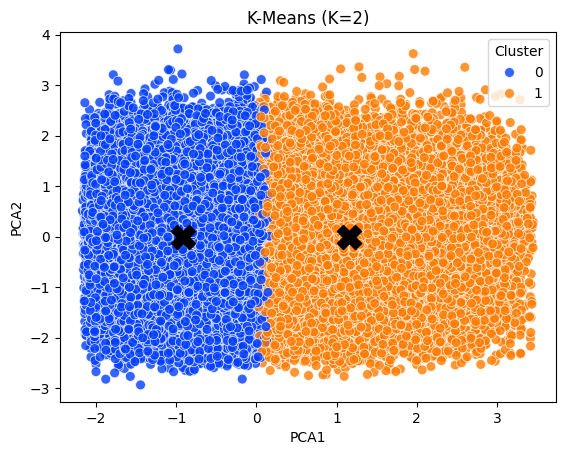

Silhouette Score (K=2): 0.24853337306898915
Inertia: 218060.45828598976


In [ ]:
0
features = ['Age', 'Monthly Income', 'Distance from Home', 'Years at Company']
X = df[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)


pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

df['PCA1'] = pca_data[:, 0]
df['PCA2'] = pca_data[:, 1]

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='bright',
    alpha=0.8,
    s=50
)


centroids = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='black',
    s=300,
    marker='X'
)

plt.title("K-Means (K=2)")
plt.show()

score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score (K=2): {score}")
print("Inertia:", kmeans.inertia_)

**Interpretation of the Results**

At k=2,
The data is divided into two main clusters with relatively clear separation between the left and right sides. The centroids are positioned logically at the center of each cluster, indicating good internal cohesion. However, slight overlap exists near the boundary, reflected by a moderate silhouette score, suggesting acceptable but not optimal clustering quality.

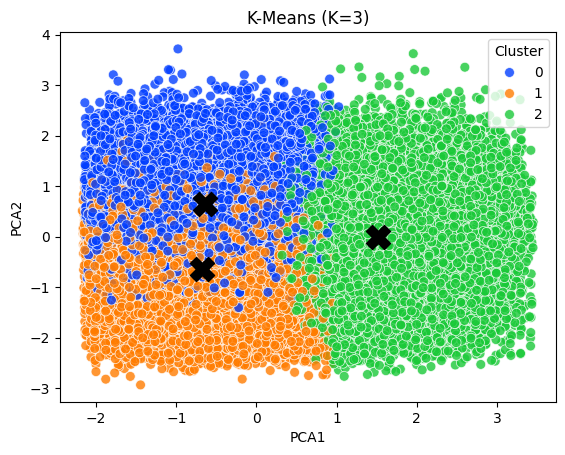

Silhouette Score (K=3): 0.22266513763209247
Inertia: 180933.14471962175


In [ ]:


features = ['Age', 'Monthly Income', 'Distance from Home', 'Years at Company']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

df['PCA1'] = pca_data[:,0]
df['PCA2'] = pca_data[:,1]

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='bright',
    alpha=0.8,
    s=50
)

centroids = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='black',
    s=300,
    marker='X'
)

plt.title("K-Means (K=3)")
plt.show()

score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score (K=3): {score}")
print("Inertia:", kmeans.inertia_)

**Interpretation of the Result**

At K=3,When increasing the number of clusters to three, the right side remains a well-defined and cohesive cluster. However, the left side is split into two groups (upper and lower) despite the lack of clear separation, resulting in noticeable overlap. This suggests unnecessary partitioning by the algorithm and a decrease in clustering quality compared to K=2.

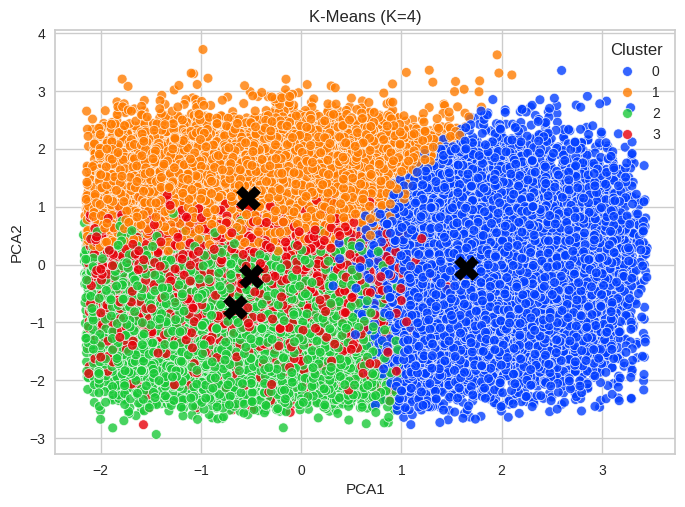

Silhouette Score (K=4): 0.21537408165337005
Inertia (K=4): 156969.74515971454


In [ ]:

features = ['Age', 'Monthly Income', 'Distance from Home', 'Years at Company']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)


pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

df['PCA1'] = pca_data[:, 0]
df['PCA2'] = pca_data[:, 1]

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='bright',
    alpha=0.8,
    s=50
)


centroids = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='black',
    s=300,
    marker='X'
)

plt.title("K-Means (K=4)")
plt.show()

score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score (K=4): {score}")
print(f"Inertia (K=4): {kmeans.inertia_}")

**Interpretation of the Results**

At k=4,with four clusters, the segmentation becomes more complex and less meaningful. While the right side remains relatively clear, the left side is divided into three highly overlapping clusters, especially in the central region. This significant overlap indicates that the algorithm is forcing the data into more clusters than necessary, resulting in a noticeable decline in clustering quality.

## **6) Evaluation and Comparison**

 ### **6.1) Classification**
we applied three different data splits were applied for each classification technique (90/10, 80/20, and 70/30).

The Decision Tree model was evaluated using both Gini Index and Entropy criteria.

The results are presented in the following tables, which include the accuracy values and the confusion matrices for each model and partition.



### **confusion matrix**

The confusion matrix below shows the classification results for this model.

* **Gini index 90/10**

    [[2212 1325]<br>
    [1316 2597]]


---


* **Gini index 80/20**

   [[4431 2643]<br>
   [2695 5131]]


---


* **Gini index 70/30**

   [[6666 3945]<br>
   [3972 7767]]



---


* **IG Entropy 90/10**

  [[2229 1276]<br>
  [1362 2583]]


---


* **IG Entropy 80/20**

  [[4377 2658]<br>
  [2657 5208]]


---


* **IG Entropy 70/30**

  [[6622 3973]<br>
  [3846 7909]]



This table presents the accuracy results for both classification criteria

In [ ]:
results = {
    'Criterion': ['Gini', 'Gini', 'Gini',
                  'Entropy', 'Entropy', 'Entropy'],
    'Split':     ['90/10', '80/20', '70/30',
                  '90/10', '80/20', '70/30'],
    'Accuracy':    [64.55, 64.17, 64.58,
                    64.59, 64.33, 65.02],
    'Precision':   [66.22, 66.00, 66.32,
                    66.93, 66.21, 66.56],
    'Sensitivity': [66.37, 65.56, 66.16,
                    65.48, 66.22, 67.28],
    'Specificity': [62.54, 62.64, 62.82,
                    63.59, 62.22, 62.50]
}

df_results = pd.DataFrame(results).set_index(['Criterion', 'Split'])

print("Classification Evaluation Results:")
display(df_results)

Classification Evaluation Results:


Accuracy  Precision  Sensitivity  Specificity
Criterion Split                                               
Gini      90/10     64.55      66.22        66.37        62.54
          80/20     64.17      66.00        65.56        62.64
          70/30     64.58      66.32        66.16        62.82
Entropy   90/10     64.59      66.93        65.48        63.59
          80/20     64.33      66.21        66.22        62.22
          70/30     65.02      66.56        67.28        62.50

**For Gini Index:**
The results show that the classification performance is relatively
similar across the three partitions, with accuracy values  
 64.55% (90/10), 64.17% (80/20),and 64.58% (70/30).

Among the tested partitions, the 70/30 split achieved the highest
accuracy (64.58%), highest precision (66.32%), and highest
specificity (62.82%), Although the 70/30 split has a slightly lower Sensitivity (66.16%)
compared to the 90/10 split (66.37%), the difference is minimal.
The 70/30 split outperforms the other partitions in Accuracy,
Precision, and Specificity, making it the best overall partition
for the Gini criterion. This suggests that using a larger testing
set provides more reliable and stable classification results.

The decision tree below was generated using the Gini index and
the 70/30 data partition.

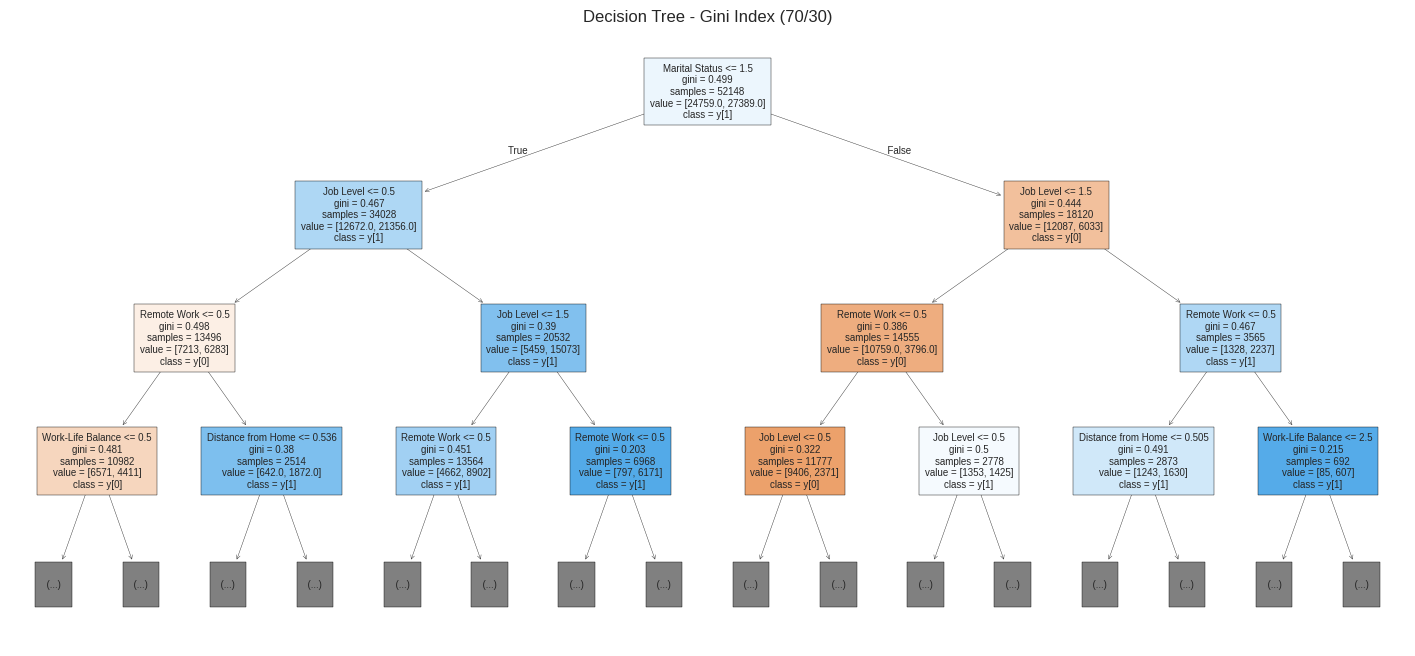

In [ ]:
plt.figure(figsize=(18,8))

tree.plot_tree(
    model_gini_70,
    feature_names=fn,
    class_names=True,
    filled=True,
    max_depth=3,
    fontsize=7
)

plt.title("Decision Tree - Gini Index (70/30)")
plt.show()

**For Entropy (Information Gain):**

The results show that the classification performance is relatively
similar across the three partitions, with accuracy values of
64.59% (90/10), 64.33% (80/20), and 65.02% (70/30).

Among the tested partitions, the 70/30 split achieved the highest
accuracy (65.02%) and highest sensitivity (67.28%), which are the
most critical metrics for predicting employee attrition. Although
the 90/10 split achieved higher precision (66.93%) and specificity
(63.59%), the difference is minimal. Therefore, the 70/30 split
is selected as the best overall partition for the Entropy criterion.

The decision tree below was generated using the Entropy criterion
and the 70/30 data partition.

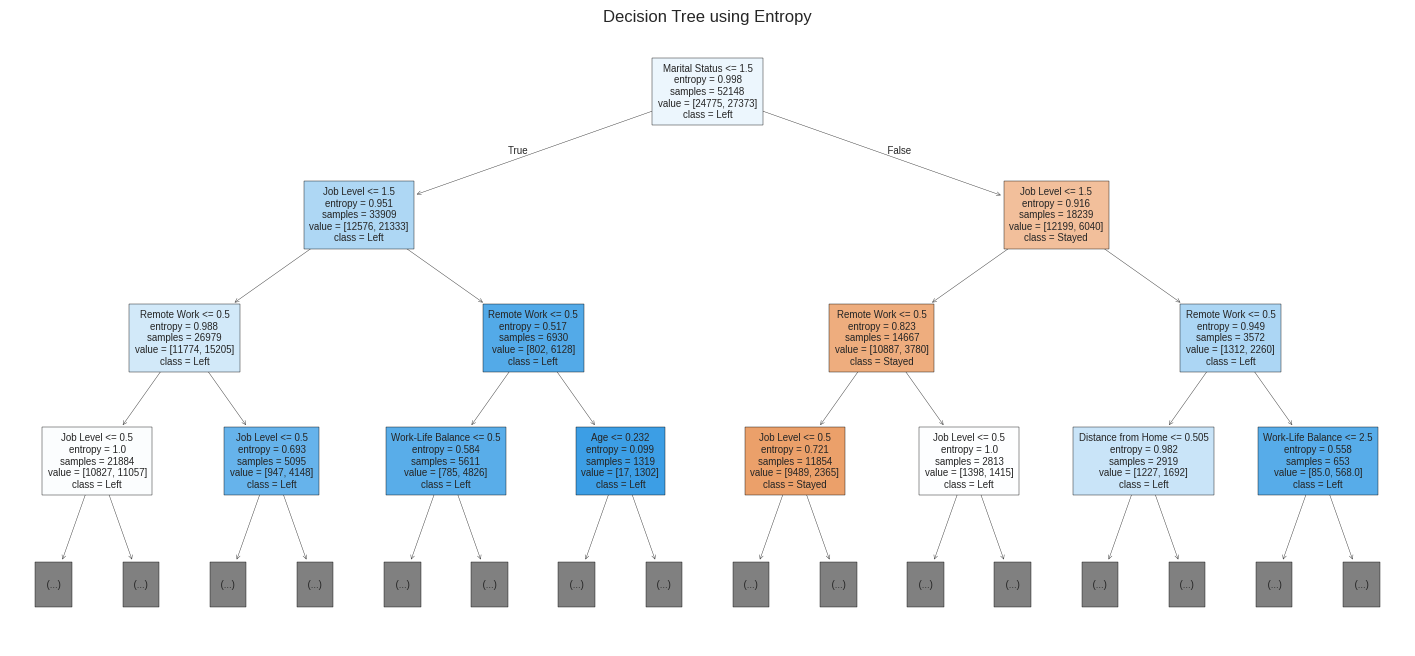

In [ ]:
# Create a figure to display the tree
plt.figure(figsize=(18,8))

# Plot the decision tree model that was trained using entropy
tree.plot_tree(
    model_entropy_70,               # The trained decision tree model
    feature_names=fn,     # Feature names from the dataset
    class_names=["Stayed","Left"], # Class labels for Attrition
    filled=True,                  # Color the nodes for better visualization
    max_depth=3,
    fontsize=7
)

# Add a title to the plot
plt.title("Decision Tree using Entropy")

# Display the tree
plt.show()

**Best Result:**

The best result was achieved using the Entropy criterion with
the 70/30 split. This gave the highest accuracy of 65.02% and
the highest sensitivity of 67.28%, meaning it was the most
successful in correctly identifying employees who are likely
to leave. Based on these results, we selected Entropy with
the 70/30 split as the best overall setting.

### **6.2** **Clustering**

**Justification for Elbow Method and Silhouette Coefficient:**

Based solely on visual inspection catter plots and inertia values, it was not possible to confidently determine the optimal number of clusters K Each increase in K improves compactness mathematically, but the separation between groups remains visually weak. Therefore, we applied the Elbow Method and Silhouette Coefficient as quantitative evaluation techniques to objectively assess clustering performance and identify the optimal K based on a balance between compactness and separation quality.




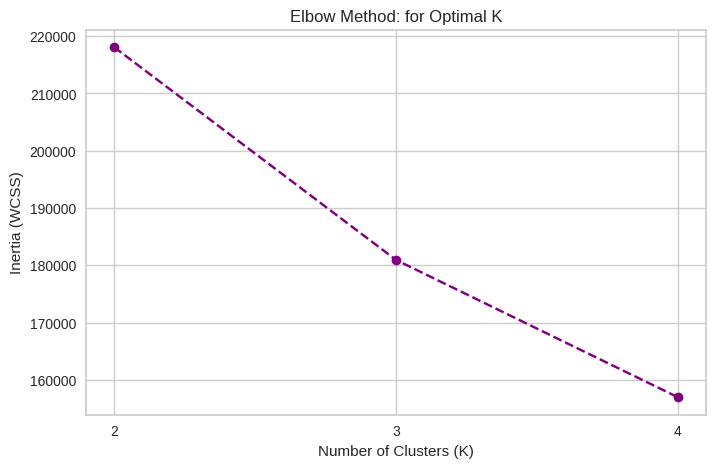

Inertia for K=2: 218060.46
Inertia for K=3: 180933.14
Inertia for K=4: 156969.75


In [ ]:
# Applying the Elbow Method to find the best K
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

features = ['Age', 'Monthly Income', 'Distance from Home', 'Years at Company']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# List to store the Inertia for each K
inertias = []
k_values = [2, 3, 4]

# Loop through each K value
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

# Elbow Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', color='purple', linestyle='--')
plt.title('Elbow Method: for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Display values
for i, k in enumerate(k_values):
    print(f"Inertia for K={k}: {inertias[i]:.2f}")


**Elbow Method Interpretation:**

The Elbow plot shows the inertia values for each value of K:
- K=2: 218060.46
- K=3: 180933.14
- K=4: 156969.75

The inertia decreases consistently as K increases. However, the plot does not show a clear "elbow" point where the decrease slows down significantly. Instead, the curve shows a gradual and steady decline, making it difficult to determine the optimal number of clusters based on this method alone.

Therefore, the Silhouette Coefficient will be used as an additional evaluation metric to help identify the best value of K.

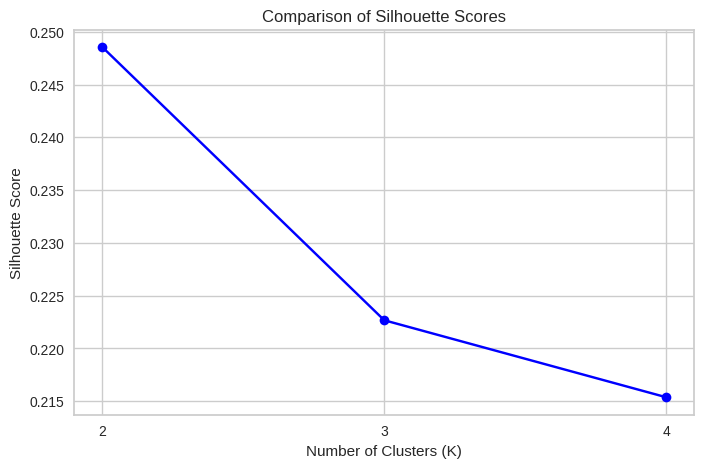

Silhouette Score for K=2: 0.2485
Silhouette Score for K=3: 0.2227
Silhouette Score for K=4: 0.2154


In [ ]:
#
# Calculating Silhouette Coefficient for metric evaluation
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# تحديد الأعمدة المستخدمة
features = ['Age', 'Monthly Income', 'Distance from Home', 'Years at Company']
X = df[features]

# تطبيع البيانات
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# List to store silhouette scores for comparison
silhouette_scores = []
k_values = [2, 3, 4]

# Evaluate each size of K
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Visual representation (Bar Chart)
plt.figure(figsize=(8, 5))
plt.plot([str(k) for k in k_values], silhouette_scores, marker='o', color='blue')
plt.title('Comparison of Silhouette Scores')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

# Display scores
for i, k in enumerate(k_values):
    print(f"Silhouette Score for K={k}: {silhouette_scores[i]:.4f}")

**Silhouette Score Interpretation:**

The Silhouette scores for each value of K are as follows:
- K=2: 0.2485
- K=3: 0.2227
- K=4: 0.2154

The results show a clear trend: as K increases, the Silhouette Score consistently decreases. This indicates that adding more clusters weakens the separation between groups. K=2 achieves the highest score, meaning it provides the most well separated and cohesive clusters among the three candidates.

However, all three scores fall below the 0.25 threshold, which suggests that the dataset lacks strong natural groupings.

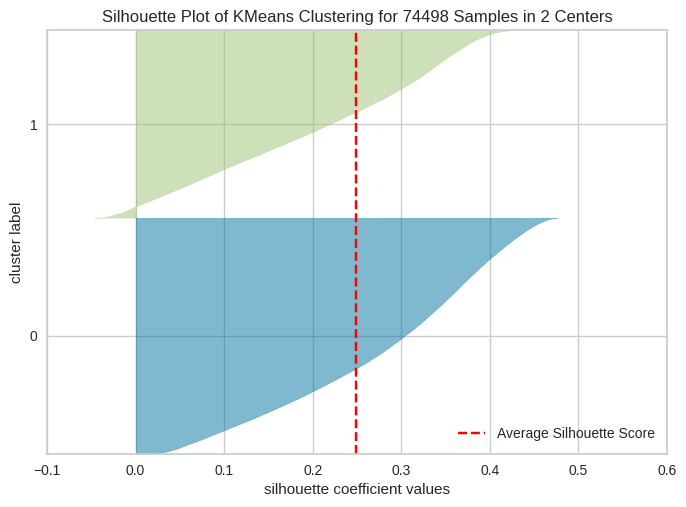

The average silhouette score for K=2 is: 0.24853337306898915


In [ ]:

from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# : Initialize the KMeans model
model = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, random_state=42)

# Set up the SilhouetteVisualizer
# This tool helps in evaluating the density and separation between clusters
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')

# Fit the visualizer to the preprocessed numerical data
visualizer.fit(X_scaled)

# Finalize and render the figure
# This plot will show the silhouette coefficient for each sample in each cluster
visualizer.show()

# Output the average silhouette score
print(f"The average silhouette score for K=2 is: {visualizer.silhouette_score_}")

**Silhouette Plot for K=2 (Average Score: 0.2485)**

 The average silhouette score of 0.2485 indicates significant data overlap and a lack of clearly separated natural clusters. However, the similar thickness of both clusters demonstrates a well-balanced distribution of samples, meaning no single cluster dominates the dataset. Furthermore, the near absence of negative values shows that the misclassification rate between the two clusters is almost negligible. Ultimately, most data points are concentrated near the decision boundaries, explaining the overall low score despite the balanced partitioning.


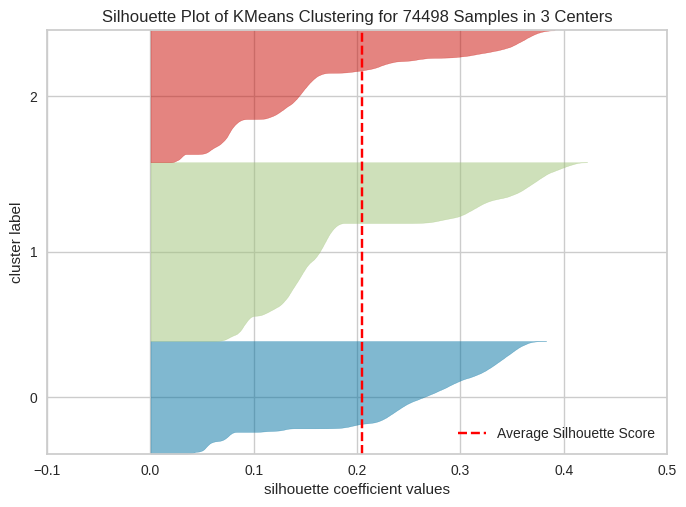

The average silhouette score for K=3 is: 0.20434469049167842


In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# : Initialize the KMeans model with t
model = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=42)

# Set up the SilhouetteVisualizer
# This tool helps in evaluating the density and separation between clusters
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')

# Fit the visualizer to the preprocessed numerical data
visualizer.fit(X_scaled)

# Finalize and render the figure
# This plot will show the silhouette coefficient for each sample in each cluster
visualizer.show()

# Output the average silhouette score
print(f"The average silhouette score for K=3 is: {visualizer.silhouette_score_}")

  **Silhouette Plot for K=3 (Average Score: 0.2043):**
  
The average silhouette score has decreased to 0.2043, indicating increased data overlap and poorer cluster separation compared to the two-cluster model. While the three clusters still maintain a relatively balanced distribution of samples, the overall quality of cohesion has noticeably declined. Most significantly, there is a visible emergence of negative silhouette values across multiple clusters, demonstrating a higher rate of misclassification where samples are actually closer to neighboring clusters. Furthermore, the heavy concentration of data points near the zero boundary across all three groups reinforces the lack of distinct, natural groupings within this dataset.

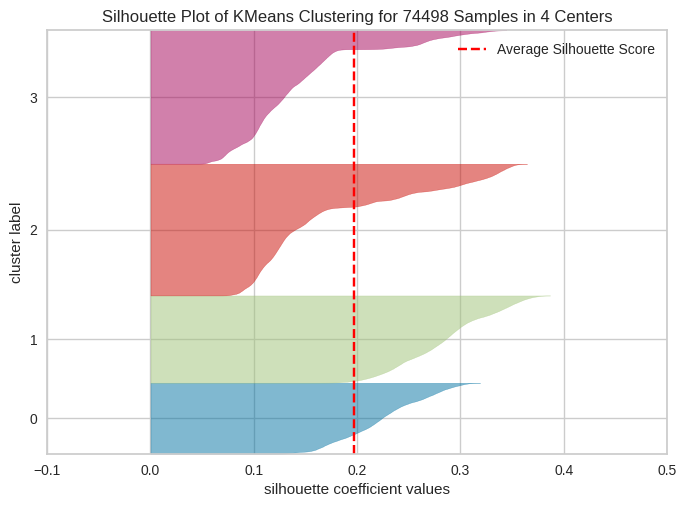

The average silhouette score for K=4 is: 0.19703976027670841


In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# : Initialize the KMeans model w
model = KMeans(n_clusters=4, init='k-means++', n_init=10, max_iter=300, random_state=42)

# Set up the SilhouetteVisualizer
# This tool helps in evaluating the density and separation between clusters
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')

# Fit the visualizer to the preprocessed numerical data
visualizer.fit(X_scaled)

# Finalize and render the figure
# This plot will show the silhouette coefficient for each sample in each cluster
visualizer.show()

# Output the average silhouette score
print(f"The average silhouette score for K=4 is: {visualizer.silhouette_score_}")

**Silhouette Plot for K=4 (Average Score: 0.1970):**

The average silhouette score has further declined to 0.1970, indicating even greater data overlap and poorer cluster separation compared to the previous models. While the four clusters maintain a somewhat reasonable distribution, slight variations in cluster thickness are beginning to emerge, suggesting a less balanced partition than K=2 or K=3. More importantly, there is a visible increase in negative silhouette values across almost all clusters, which signifies a higher rate of misclassification where many samples are likely assigned to the wrong group. Ultimately, the dense concentration of points near the zero boundary and the consistently decreasing average score confirm that forcing the data into four clusters does not align well with its natural structure

In [ ]:
# Detailed Comparison for Selected K Values
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Based on Elbow and Silhouette, we select three candidate values (2, 3, 4)
chosen_K = [2, 3, 4]
cluster_details = []

for k in chosen_K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans.fit_predict(numeric_df_final)

    inertia = kmeans.inertia_
    sil = silhouette_score(X_scaled, labels_k)

    cluster_details.append({"K": k, "WCSS": inertia, "Silhouette": sil})


cluster_results_df = pd.DataFrame(cluster_details).set_index('K').T
cluster_results_df.index = ['total within-cluster sum of square', 'Average Silhouette width']
cluster_results_df.columns = [f'K={k}' for k in chosen_K]

print("K-means Clustering Evaluation:")
display(cluster_results_df)

K-means Clustering Evaluation:


,K=2,K=3,K=4
total within-cluster sum of square,129586.722646,113000.156980,100851.817803
Average Silhouette width,0.247909,0.204345,0.197040


The table summarizes the clustering results for K=2, K=3, and K=4.
Inertia decreases as K increases, while the Average Silhouette
Width also decreases. Although K=2 achieves the highest Silhouette
Score (0.2479), K=3 was selected as the optimal number of clusters
because splitting the data into only two groups closely resembles
the original class label (Attrition: Yes/No), which does not add
new insights. K=3 introduces a third group that reveals additional
patterns in the data, making it more meaningful for analysis.

# **7) Findings and Discussion**

In this section, the results of classification and clustering
techniques are presented and discussed in order to interpret
employee attrition patterns and evaluate model performance.

#### **7.1) Classification Results**
One classification model was applied: Decision Tree, and its
performance was evaluated using accuracy across different data
splits (90/10, 80/20, and 70/30).

- The Decision Tree model was tested using two splitting criteria:
  Gini Index and Entropy.
- The results showed that Entropy performed slightly better than
  Gini Index, especially under the 70/30 split.
- The 70/30 split provided the most stable and reliable performance
  due to the balance between training and testing data.

The Decision Tree visualization revealed that the most important
features in predicting employee attrition are Marital Status,
Job Level, and Remote Work, as they appear at the top of the
tree and are used for the primary splits. This indicates that these factors have a strong influence on employee turnover decisions.

#### **7.2) Clustering Results**
K-Means clustering was applied using different values of K
(K=2, K=3, K=4), and the results were evaluated using Inertia,
Silhouette Score, and the Elbow Method.

- The Elbow Method showed a steady decrease in inertia without
  a clear elbow point, making it difficult to identify the
  optimal K based on this method alone.
- K=3 was selected as the optimal number of clusters because it
  provides more meaningful segmentation beyond a simple two-group
  split, despite K=2 having a slightly higher Silhouette Score.
- Increasing K to 4 reduced cluster quality and increased overlap
  between groups.
- All Silhouette scores remained below 0.25, confirming that the
  dataset does not have strong natural groupings.

#### **7.3) Interpretation of Results**
- Marital Status, Job Level, and Remote Work are the most
  influential factors in predicting employee attrition.
- The Decision Tree successfully predicts employee behavior
  based on these features.
- The clustering results showed significant overlap between
groups, suggesting that the dataset does not have strong natural
groupings based on the selected features.

#### **7.4) Best Model Selection**
- The best classification configuration is Decision Tree with
  **Entropy criterion under the 70/30 split**, due to its slightly
  higher accuracy.
- Although no clear natural groupings were found in the dataset,
  **K=3 was selected as the best clustering configuration** as it
  provides slightly more meaningful segmentation compared to
  K=2 and K=4.

#### **7.5) Visualization Support**
- Decision Tree diagrams were used to explain how classification
  decisions are made.
- Cluster scatter plots (Age vs Monthly Income) were used to
  visualize employee groupings.

#### **7.6) Relation to Research Paper**
In our study, we used a Decision Tree classifier with Gini and Entropy and achieved an accuracy of around 64–65%. In comparison, the research paper by El-Rayes et al. (Predicting Employee Attrition Using Tree-Based Models) used tree-based and ensemble models such as Random Forest, which achieved slightly higher performance.

Both our results and the research findings show that tree-based methods are effective for predicting employee attrition, although more advanced models can provide better accuracy.

#**8) References**
[1] N. El-Rayes, M. Fang, M. Smith, and S. M. Taylor,
“Predicting employee attrition using tree-based models,”
International Journal of Organizational Analysis, 2020.  

[2] IBM, “Employee Attrition Dataset,” Kaggle. [Online].
Available: https://www.kaggle.com/

[3] F. Pedregosa et al.,
“Scikit-learn: Machine Learning in Python,”
Journal of Machine Learning Research, vol. 12, pp. 2825–2830, 2011.
